In [3]:
import pandas as pd
from pathlib import Path
from algo.backtester import backtest

# === Step 1: Load CSV and set 'date' as datetime index ===
csv_path = Path("data_processed/HDFCBANK_5minute_feat.csv")
df = pd.read_csv(csv_path, parse_dates=["date"], index_col="date")

# === Step 2: Validate required columns ===
required_cols = ["close", "supertrend_dir", "vwap", "ema_8", "ema_21","rsi_14"]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# === Step 3: Drop NaNs from key indicators ===
df = df.dropna(subset=required_cols)

# === Step 4: Run Backtest ===
trades, metrics= backtest(
    df=df,
    capital=100_000,
    contract_size=1,
    debug=True
)

# === Step 5: Print Dataset Summary ===
print(f"\n⏳ Backtest Duration: {df.index.min().date()} → {df.index.max().date()}")
print(f"📅 Total Days: {(df.index.max() - df.index.min()).days + 1}")
print(f"📊 Total Bars: {df.shape[0]}")

# === Step 6: Print Trades and Metrics ===
print("\n=== 🧾 Trade Log ===")
print(trades)

print("\n=== 📊 Backtest Metrics ===")
for k, v in metrics.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

# === Step 7: Optional - Trades per Day ===
if not trades.empty:
    trades["day"] = pd.to_datetime(trades["entry_ts"]).dt.date  # <-- FIXED
    print("\n📈 Trades Per Day:")
    print(trades.groupby("day").size())

# Print top 10 TRAIL winners and all EOD winners for diagnosis
print("\n=== Top 10 TRAIL Winners ===")
print(trades[trades["exit_reason"] == "TRAIL"].sort_values("gross_pnl", ascending=False).head(10)[["entry_ts", "exit_ts", "entry_price", "exit_price", "gross_pnl"]])

print("\n=== Top 10 EOD Winners ===")
print(trades[trades["exit_reason"] == "EOD"].sort_values("gross_pnl", ascending=False).head(10)[["entry_ts", "exit_ts", "entry_price", "exit_price", "gross_pnl"]])


# === Step 8: Save to CSV ===
trades.to_csv("backtest_trades_output.csv")


2024-02-26 14:45:00 ENTRY SHORT @ 1426.55
[fees] total=1.52 on qty=1 from 1426.55 → 1421.95
2024-02-26 15:25:00 EXIT EOD @ 1421.95 x1 PnL=3.08 EQ=100003.08 (SHORT)
2024-02-27 11:15:00 ENTRY LONG @ 1419.85
[fees] total=1.51 on qty=1 from 1419.85 → 1419.35
2024-02-27 14:20:00 EXIT TRAIL @ 1419.35 x1 PnL=-2.01 EQ=100001.07 (LONG)
2024-02-27 14:30:00 ENTRY SHORT @ 1421.80
[fees] total=1.51 on qty=1 from 1421.80 → 1420.85
2024-02-27 15:25:00 EXIT EOD @ 1420.85 x1 PnL=-0.56 EQ=100000.51 (SHORT)
2024-02-28 09:45:00 ENTRY LONG @ 1422.25
[fees] total=1.51 on qty=1 from 1422.25 → 1412.25
2024-02-28 10:55:00 EXIT TRAIL @ 1412.25 x1 PnL=-11.51 EQ=99989.00 (LONG)
2024-02-28 12:15:00 ENTRY LONG @ 1418.40
[fees] total=1.50 on qty=1 from 1418.40 → 1407.80
2024-02-28 13:10:00 EXIT TRAIL @ 1407.80 x1 PnL=-12.10 EQ=99976.89 (LONG)
2024-02-28 13:50:00 ENTRY LONG @ 1416.75
[fees] total=1.50 on qty=1 from 1416.75 → 1406.00
2024-02-28 15:15:00 EXIT TRAIL @ 1406.00 x1 PnL=-12.25 EQ=99964.64 (LONG)
2024-02-29 

In [5]:
# Assuming 'trades' is your DataFrame of trade results

# Filter for TRAIL exits and sort by gross_pnl (ascending for worst trades)
bottom_10_trail = trades[trades["exit_reason"] == "TRAIL"].sort_values("gross_pnl").head(10)

print("=== Bottom 10 TRAIL Losers ===")
print(bottom_10_trail[["entry_ts", "exit_ts", "entry_price", "exit_price", "gross_pnl"]])


=== Bottom 10 TRAIL Losers ===
               entry_ts             exit_ts  entry_price  exit_price  \
382 2025-04-21 09:15:00 2025-04-21 10:20:00      1945.20     1920.40   
96  2024-06-24 09:25:00 2024-06-24 11:00:00      1649.35     1668.70   
230 2024-11-13 09:15:00 2024-11-13 10:40:00      1727.20     1710.05   
407 2025-05-15 11:45:00 2025-05-15 13:05:00      1905.00     1922.00   
236 2024-11-21 09:25:00 2024-11-21 10:45:00      1752.45     1735.50   
423 2025-06-02 09:15:00 2025-06-02 15:00:00      1917.80     1934.70   
388 2025-04-25 09:25:00 2025-04-25 10:45:00      1921.80     1905.30   
368 2025-04-03 09:20:00 2025-04-03 11:50:00      1787.40     1803.80   
103 2024-06-28 09:20:00 2024-06-28 13:05:00      1704.40     1688.20   
317 2025-02-04 10:50:00 2025-02-04 12:15:00      1689.40     1705.25   

     gross_pnl  
382     -24.80  
96      -19.35  
230     -17.15  
407     -17.00  
236     -16.95  
423     -16.90  
388     -16.50  
368     -16.40  
103     -16.20  
317   

In [2]:
metrics

{'Trades': 460,
 'WinRate': np.float64(0.3521739130434783),
 'GrossPnL': np.float64(-246.35000000000377),
 'Fees': np.float64(835.7727722924999),
 'NetPnL': np.float64(-1082.1227722925037),
 'EquityFinal': np.float64(98917.8772277074)}

In [1]:
import pandas as pd

# Load your trades file
df = trades  # update path if needed

# 1. Show columns to confirm schema
print("Columns:", df.columns.tolist())

# 2. PnL by exit reason
print("\nPnL by exit reason:")
print(df.groupby("exit_reason")["pnl"].agg(['count', 'mean', 'sum']))

# 3. Average hold duration (in minutes) by exit reason, if available
if "held_min" in df.columns:
    print("\nAverage hold duration by exit reason:")
    print(df.groupby("exit_reason")["held_min"].agg(['mean', 'median']))

# 4. % of TIME exits that are profitable
if "exit_reason" in df.columns and "pnl" in df.columns:
    time_trades = df[df["exit_reason"] == "TIME"]
    percent_profitable_time = (time_trades["pnl"] > 0).mean() * 100
    avg_pnl_time = time_trades["pnl"].mean()
    print(f"\n% of TIME exits that are profitable: {percent_profitable_time:.2f}%")
    print(f"Average PnL of TIME exits: {avg_pnl_time:.2f}")

# 5. Distribution of returns for each exit reason
print("\nReturn distribution by exit reason:")
print(df.groupby("exit_reason")["pnl"].describe())

# 6. Average trades/day and days with 0 trades
if "exit_ts" in df.columns:
    df["day"] = pd.to_datetime(df["exit_ts"]).dt.date
    trades_per_day = df.groupby("day").size()
    print(f"\nAverage trades per day: {trades_per_day.mean():.2f}")
    print(f"Min/Max trades per day: {trades_per_day.min()} / {trades_per_day.max()}")
    print(f"Days with zero trades (out of 305): {305 - trades_per_day.count()}")


NameError: name 'trades' is not defined

In [1]:
import itertools
import pandas as pd
from pathlib import Path
from algo.backtester import backtest

# Define grid
TRAIL_ATR_LIST = [1.0, 1.25, 1.5, 2.0]
ADX_LIST = [12, 15, 18, 20]
csv_path = Path("data_processed/HDFCBANK_5minute_feat.csv")
df = pd.read_csv(csv_path, parse_dates=["date"], index_col="date")
results = []

for trail_atr, adx_th in itertools.product(TRAIL_ATR_LIST, ADX_LIST):
    trades, metrics = backtest(
        df=df,
        capital=100_000,
        contract_size=1,
        debug=False,
        TRAIL_ATR=trail_atr,
        ADX_TH=adx_th
    )
    avg_trades_per_day = metrics["Trades"] / ((df.index.max() - df.index.min()).days + 1)
    results.append({
        "TRAIL_ATR": trail_atr,
        "ADX_TH": adx_th,
        "Trades": metrics["Trades"],
        "WinRate": metrics["WinRate"],
        "NetPnL": metrics["NetPnL"],
        "EquityFinal": metrics["EquityFinal"],
        "AvgTradesPerDay": avg_trades_per_day,
        "GrossPnL": metrics["GrossPnL"],
        "Fees": metrics["Fees"]
    })

# Show results sorted by NetPnL
df_results = pd.DataFrame(results).sort_values("NetPnL", ascending=False)
print(df_results.head(10))


    TRAIL_ATR  ADX_TH  Trades   WinRate       NetPnL   EquityFinal  \
15       2.00      20     553  0.301989 -1019.694458  98980.305542   
14       2.00      18     632  0.295886 -1126.910302  98873.089698   
13       2.00      15     722  0.299169 -1211.899569  98788.100431   
11       1.50      20     639  0.269171 -1235.452925  98764.547075   
7        1.25      20     692  0.260116 -1324.979543  98675.020457   
12       2.00      12     791  0.293300 -1405.862416  98594.137584   
3        1.00      20     757  0.247028 -1435.674260  98564.325740   
10       1.50      18     742  0.265499 -1485.403247  98514.596753   
9        1.50      15     853  0.271981 -1584.459899  98415.540101   
6        1.25      18     801  0.258427 -1594.753352  98405.246648   

    AvgTradesPerDay  GrossPnL         Fees  
15         1.108216    -20.95   998.744458  
14         1.266533     13.55  1140.460302  
13         1.446894     92.95  1304.849569  
11         1.280561    -80.30  1155.152925  
7   

In [4]:
cross_exits = trades[trades["exit_reason"] == "CROSS_EXIT"]
n_cross = len(cross_exits)
n_win = (cross_exits["pnl"] > 0).sum()
n_loss = (cross_exits["pnl"] <= 0).sum()
win_pct = n_win / n_cross * 100 if n_cross > 0 else 0

print(f"CROSS_EXIT win count:   {n_win} / {n_cross} ({win_pct:.2f}%)")
print(f"CROSS_EXIT loss count:  {n_loss} / {n_cross} ({100-win_pct:.2f}%)")
print("\nAverage PnL of winning CROSS_EXIT:", cross_exits[cross_exits['pnl'] > 0]['pnl'].mean())
print("Average PnL of losing  CROSS_EXIT:", cross_exits[cross_exits['pnl'] <= 0]['pnl'].mean())


CROSS_EXIT win count:   0 / 0 (0.00%)
CROSS_EXIT loss count:  0 / 0 (100.00%)

Average PnL of winning CROSS_EXIT: nan
Average PnL of losing  CROSS_EXIT: nan


In [3]:
# Ensure 'exit_ts' is datetime if not already
trades["exit_ts"] = pd.to_datetime(trades["exit_ts"])

# Create a new column for just the date part
trades["trade_day"] = trades["exit_ts"].dt.date

# Count trades per day
trade_counts = trades.groupby("trade_day").size()

# Print summary
print("\n📈 Trade Count Per Day:")
print(trade_counts)

# Basic stats
print(f"\n📊 Average Trades/Day: {trade_counts.mean():.2f}")
print(f"🔢 Min/Max Trades/Day: {trade_counts.min()} / {trade_counts.max()}")
print(f"📅 Total Days Traded: {trade_counts.count()}")



📈 Trade Count Per Day:
trade_day
2024-02-26     6
2024-02-27     2
2024-02-28     4
2024-02-29     3
2024-03-01     5
              ..
2025-07-02    10
2025-07-03     6
2025-07-04     5
2025-07-07     2
2025-07-08     3
Length: 322, dtype: int64

📊 Average Trades/Day: 4.20
🔢 Min/Max Trades/Day: 1 / 11
📅 Total Days Traded: 322


In [7]:
trades

,exit_ts,side,entry_price,exit_price,exit_reason,fees,qty,pnl,equity,day,trade_day
entry_ts,,,,,,,,,,,
2024-02-26 11:15:00,2024-02-26 12:00:00,BUY,1427.27585,1427.400000,TIME,1.521128,1,-1.396978,99998.603022,2024-02-26,2024-02-26
2024-02-26 12:57:00,2024-02-26 13:42:00,BUY,1432.03060,1430.550000,TIME,1.525163,1,-3.005763,99995.597259,2024-02-26,2024-02-26
2024-02-26 13:45:00,2024-02-26 14:30:00,BUY,1435.78435,1433.200000,TIME,1.528454,1,-4.112804,99991.484455,2024-02-26,2024-02-26
2024-02-27 10:48:00,2024-02-27 11:33:00,BUY,1421.62020,1420.650000,TIME,1.514397,1,-2.484597,99988.999858,2024-02-27,2024-02-27
2024-02-27 12:57:00,2024-02-27 13:42:00,BUY,1424.42300,1424.900000,TIME,1.518314,1,-1.041314,99987.958544,2024-02-27,2024-02-27
...,...,...,...,...,...,...,...,...,...,...,...
2025-07-07 10:57:00,2025-07-07 11:42:00,BUY,1994.69270,1989.700000,TIME,2.122534,1,-7.115234,96707.947110,2025-07-07,2025-07-07
2025-07-07 11:57:00,2025-07-07 12:27:00,SELL,1983.91410,1989.500000,TREND_FLIP,2.117848,1,-7.703748,96700.243362,2025-07-07,2025-07-07
2025-07-07 12:42:00,2025-07-07 13:27:00,BUY,1992.39040,1991.000000,TIME,2.122397,1,-3.512797,96696.730565,2025-07-07,2025-07-07


In [4]:
print(trades["exit_reason"].value_counts())

exit_reason
STOP_LOSS    381
TP            75
TIME          23
BREAKEVEN     21
Name: count, dtype: int64


In [9]:
trades.columns

Index(['exit_ts', 'side', 'entry_price', 'exit_price', 'exit_reason', 'fees',
       'qty', 'pnl', 'equity', 'day', 'trade_day'],
      dtype='object')

     slot  n_trades   winrate   avg_pnl   gross_pnl
0   09:00       159  0.188679 -4.136139 -657.646052
1   09:30        45  0.311111 -2.631518 -118.418317
2   10:00        77  0.181818 -3.618277 -278.607310
3   10:30       109  0.119266 -3.622856 -394.891259
4   11:00       120  0.091667 -3.887949 -466.553842
5   11:30        89  0.112360 -3.283869 -292.264381
6   12:00       116  0.051724 -4.020470 -466.374486
7   12:30       110  0.145455 -3.346026 -368.062867
8   13:00       109  0.100917 -3.636549 -396.383887
9   13:30       133  0.150376 -3.125242 -415.657132
10  14:00       127  0.086614 -3.718571 -472.258575
11  14:30       159  0.094340 -3.585956 -570.167075


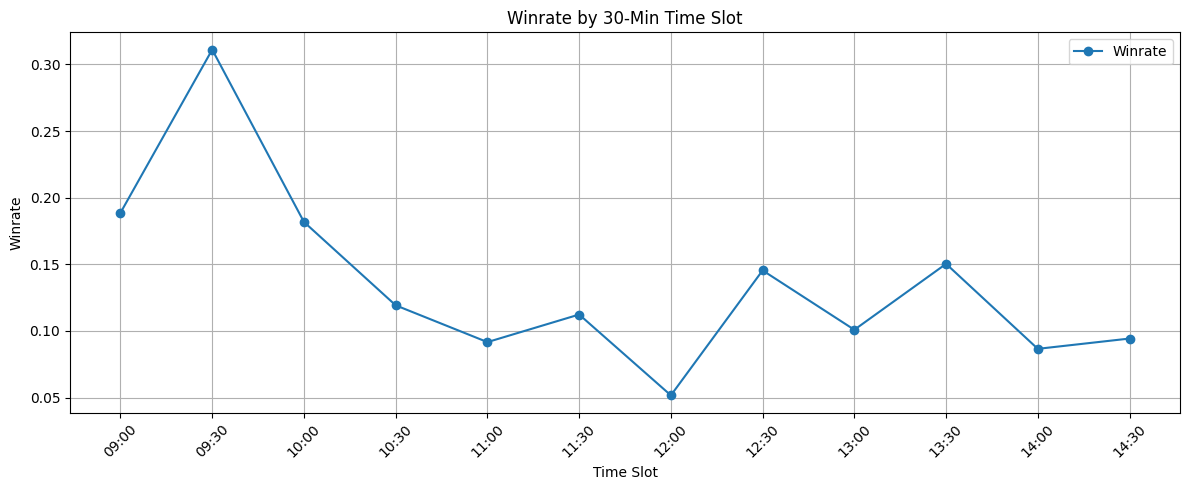

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Ensure 'entry_ts' is a datetime column ---
if "entry_ts" in trades.columns:
    trades["entry_ts"] = pd.to_datetime(trades["entry_ts"])
else:
    trades["entry_ts"] = pd.to_datetime(trades.index)

# --- 2. Create time bins (30-min slots) ---
trades["slot"] = trades["entry_ts"].dt.hour.astype(str).str.zfill(2) + ":" + \
                 (trades["entry_ts"].dt.minute // 30 * 30).astype(str).str.zfill(2)

# --- 3. Calculate stats per time bin ---
slot_stats = (
    trades.groupby("slot")
          .agg(
              n_trades=("pnl", "count"),
              winrate=("pnl", lambda x: (x > 0).mean()),
              avg_pnl=("pnl", "mean"),
              gross_pnl=("pnl", "sum")
          )
          .reset_index()
          .sort_values("slot")
)

# --- 4. Print stats ---
with pd.option_context('display.max_rows', None):
    print(slot_stats)

# --- 5. Visualize Winrate by Time Slot ---
plt.figure(figsize=(12, 5))
plt.plot(slot_stats["slot"], slot_stats["winrate"], marker='o', label="Winrate")
plt.xticks(rotation=45)
plt.title("Winrate by 30-Min Time Slot")
plt.ylabel("Winrate")
plt.xlabel("Time Slot")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
print(df.index[:10])
print(df.index[-10:])


DatetimeIndex(['2024-02-26 10:15:00', '2024-02-26 10:18:00',
               '2024-02-26 10:21:00', '2024-02-26 10:24:00',
               '2024-02-26 10:27:00', '2024-02-26 10:30:00',
               '2024-02-26 10:33:00', '2024-02-26 10:36:00',
               '2024-02-26 10:39:00', '2024-02-26 10:42:00'],
              dtype='datetime64[ns]', name='date', freq=None)
DatetimeIndex(['2025-07-08 15:00:00', '2025-07-08 15:03:00',
               '2025-07-08 15:06:00', '2025-07-08 15:09:00',
               '2025-07-08 15:12:00', '2025-07-08 15:15:00',
               '2025-07-08 15:18:00', '2025-07-08 15:21:00',
               '2025-07-08 15:24:00', '2025-07-08 15:27:00'],
              dtype='datetime64[ns]', name='date', freq=None)
